## Methodology

### Training and Iterate Collection

A ResNet-8 (~78k parameters) is trained on 15,000 CIFAR-10 samples using SGD ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, 15 epochs). The full parameter vector is stored after every mini-batch update, yielding $T = 1{,}770$ iterates.

### Windowed PCA

PCA is applied in a sliding window of 150 iterates (stride 75) over the full trajectory. Each window is centred before fitting and the top-10 explained variance ratios are extracted. The PC1 share is tracked as a function of the window centre, capturing how the effective dimensionality of local parameter-space motion evolves during training.

### Phase-wise PCA

The trajectory is partitioned into $N=6$ equally sized, non-overlapping phases. For each phase, PCA is fitted independently on the centred iterate sub-matrix and the top-5 explained variance shares are recorded. The monotonically decreasing PC1 share across phases (76.8\% $\to$ 54.3\%) indicates that early training is dominated by a single dominant direction of movement, while later phases exhibit progressively more isotropic, diffuse dynamics as the trajectory settles into a flat basin.

### Per-Phase OU Calibration

For each of the 6 phases, an Ornstein–Uhlenbeck process is separately calibrated using the same procedure as in the global calibration notebook: the restoring target is set to the phase endpoint, the diffusion $\sigma$ is estimated from the empirical per-dimension step-size standard deviation within the phase, and the restoring strength $\mu$ is swept over a grid. The best-fitting $\mu$ per phase is identified by minimising the Wasserstein distance between the OU eigenvalue spectrum and the SGD eigenvalue spectrum of that phase. Comparing the resulting $\mu^*$ values across phases quantifies how the balance between directed drift and stochastic diffusion shifts over the course of training — a decreasing $\mu^*$ in later phases would be consistent with the trajectory transitioning from gradient-driven descent towards a diffusion-dominated regime near convergence.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

TRAIN_SIZE   = 15_000
TEST_SIZE    = 5_000
BATCH_SIZE   = 128
EPOCHS       = 15
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4

WINDOW_SIZE  = 150
WINDOW_STEP  = 75
N_PCA_COMPS  = 10
N_PHASES     = 6

print(f"EPOCHS={EPOCHS}, LR={LR}, BATCH={BATCH_SIZE}, TRAIN={TRAIN_SIZE}, TEST={TEST_SIZE}")
print(f"WINDOW_SIZE={WINDOW_SIZE}, WINDOW_STEP={WINDOW_STEP}, N_PHASES={N_PHASES}")

Device: mps
EPOCHS=15, LR=0.1, BATCH=128, TRAIN=15000, TEST=5000
WINDOW_SIZE=150, WINDOW_STEP=75, N_PHASES=6


In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform_train)
full_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

train_subset = torch.utils.data.Subset(full_train, range(TRAIN_SIZE))
test_subset  = torch.utils.data.Subset(full_test,  range(TEST_SIZE))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE,
                                            shuffle=True,  num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_subset,  batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=0)

print(f"Train-Batches: {len(train_loader)}, Test-Batches: {len(test_loader)}")

Files already downloaded and verified
Files already downloaded and verified
Train-Batches: 118, Test-Batches: 40


In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_ch   = 16
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2  = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3  = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_ch, num_blocks, stride):
        layers = [block(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, num_blocks):
            layers.append(block(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


def resnet8(): return ResNet(BasicBlock, [1, 1, 1])

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"ResNet-8: {count_params(resnet8()):,} Parameter")

ResNet-8: 78,042 Parameter


In [4]:
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 55)
print("Training ResNet-8")
print("=" * 55)

model8    = resnet8().to(DEVICE)
opt8      = optim.SGD(model8.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

iterates8   = []
train_accs8 = []
test_accs8  = []
losses8     = []
step = 0

for epoch in range(EPOCHS):
    model8.train()
    epoch_loss, correct, total = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt8.zero_grad()
        outputs = model8(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        opt8.step()

        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)
        iterates8.append(np.concatenate([p.detach().cpu().numpy().ravel()
                                          for p in model8.parameters()]))
        step += 1

    train_acc = 100. * correct / total
    avg_loss  = epoch_loss / len(train_loader)
    losses8.append(avg_loss)
    train_accs8.append(train_acc)

    model8.eval()
    correct_t, total_t = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            _, predicted = model8(inputs).max(1)
            correct_t += predicted.eq(targets).sum().item()
            total_t   += targets.size(0)
    test_acc = 100. * correct_t / total_t
    test_accs8.append(test_acc)

    print(f"  Epoch {epoch+1:02d}/{EPOCHS}  loss={avg_loss:.4f}  "
          f"train={train_acc:.1f}%  test={test_acc:.1f}%")

iterates8 = np.array(iterates8)
print(f"\nSnapshots: {len(iterates8)},  Param-Dim: {iterates8.shape[1]:,}")

Training ResNet-8
  Epoch 01/15  loss=1.8854  train=28.8%  test=31.3%
  Epoch 02/15  loss=1.6207  train=38.5%  test=40.1%
  Epoch 03/15  loss=1.4525  train=46.3%  test=44.3%
  Epoch 04/15  loss=1.3382  train=51.5%  test=41.5%
  Epoch 05/15  loss=1.2315  train=56.0%  test=53.6%
  Epoch 06/15  loss=1.1285  train=59.4%  test=53.9%
  Epoch 07/15  loss=1.0736  train=61.5%  test=58.4%
  Epoch 08/15  loss=1.0043  train=63.6%  test=56.6%
  Epoch 09/15  loss=0.9752  train=65.0%  test=56.1%
  Epoch 10/15  loss=0.9325  train=66.7%  test=62.8%
  Epoch 11/15  loss=0.8884  train=68.3%  test=67.0%
  Epoch 12/15  loss=0.8843  train=68.5%  test=66.0%
  Epoch 13/15  loss=0.8494  train=69.4%  test=66.4%
  Epoch 14/15  loss=0.8096  train=71.4%  test=67.7%
  Epoch 15/15  loss=0.7862  train=72.5%  test=66.8%

Snapshots: 1770,  Param-Dim: 78,042


In [6]:
n8      = len(iterates8)
starts8 = list(range(0, n8 - WINDOW_SIZE + 1, WINDOW_STEP))

centers8   = []
eig_pct_8  = []   # Top-N_PCA_COMPS PC-Anteile in %, pro Fenster

for s in starts8:
    window          = iterates8[s:s + WINDOW_SIZE]
    window_centered = window - window.mean(axis=0)
    pca = PCA(n_components=min(N_PCA_COMPS, WINDOW_SIZE - 1))
    pca.fit(window_centered)
    centers8.append(s + WINDOW_SIZE // 2)
    eig_pct_8.append(pca.explained_variance_ratio_ * 100)

centers8  = np.array(centers8)
eig_pct_8 = np.array(eig_pct_8)

print(f"ResNet-8: {len(centers8)} Fenster")

ResNet-8: 22 Fenster


In [19]:
# ── Iterates in N_PHASES gleich große Phasen einteilen ─────────────────────────
phase_bounds   = np.linspace(0, n8, N_PHASES + 1, dtype=int)
phase_top5_pct = []   # Liste von (5,)-Arrays, eines pro Phase
phase_labels   = []

for i in range(N_PHASES):
    s, e = phase_bounds[i], phase_bounds[i + 1]
    phase_iterates = iterates8[s:e]
    phase_centered = phase_iterates - phase_iterates.mean(axis=0)

    pca = PCA(n_components=5)
    pca.fit(phase_centered)
    phase_top5_pct.append(pca.explained_variance_ratio_ * 100)
    phase_labels.append(f"Phase {i+1}\n[{s}:{e}]")

phase_top5_pct = np.array(phase_top5_pct)   # (N_PHASES, 5)


# ── Säulendiagramm ────────────────────────────────────────────────────────────
LBL, TTL, TCK = 16, 18, 16   # label / title / tick fontsize

def plot_phase_pcs(show_title=True):
    fig, ax = plt.subplots(figsize=(13, 6.5))

    x       = np.arange(N_PHASES)
    width   = 0.15
    colors5 = plt.cm.viridis(np.linspace(0, 0.85, 5))

    for pc in range(5):
        ax.bar(x + pc * width, phase_top5_pct[:, pc], width,
               label=f"PC{pc+1}", color=colors5[pc])

    if show_title:
        ax.set_title("ResNet-20 – Top-5 PC shares per phase",
                     fontsize=TTL)

    ax.set_xlabel("Phase", fontsize=LBL)
    ax.set_ylabel("Explained variance share (%)", fontsize=LBL)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(phase_labels, fontsize=13)
    ax.tick_params(axis='y', labelsize=TCK)
    ax.legend(fontsize=TCK)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

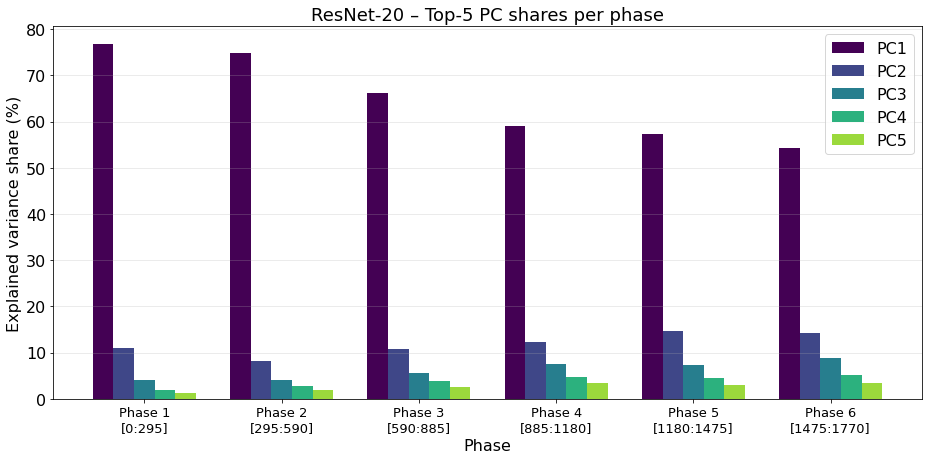

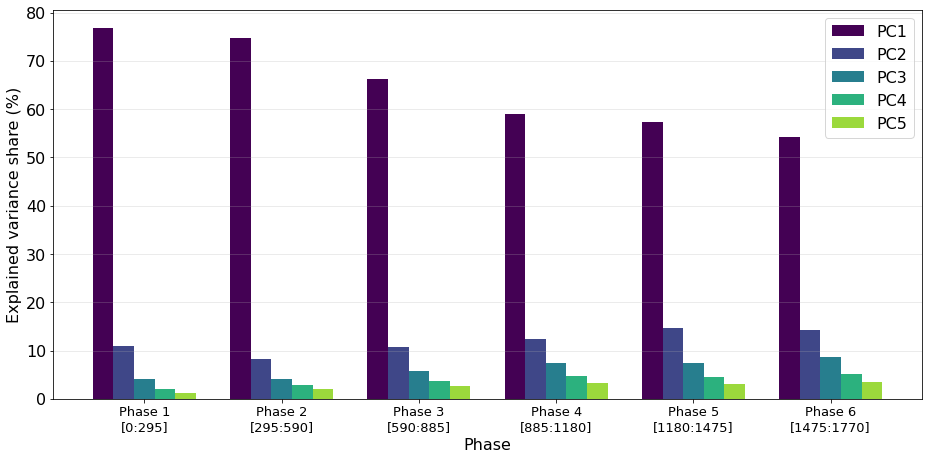

Top-5 PC shares per phase (%):
  Phase 1: PC1=76.8%, PC2=10.9%, PC3=4.1%, PC4=2.0%, PC5=1.3%
  Phase 2: PC1=74.8%, PC2=8.2%, PC3=4.1%, PC4=2.9%, PC5=2.0%
  Phase 3: PC1=66.2%, PC2=10.8%, PC3=5.7%, PC4=3.8%, PC5=2.6%
  Phase 4: PC1=59.1%, PC2=12.3%, PC3=7.5%, PC4=4.7%, PC5=3.4%
  Phase 5: PC1=57.3%, PC2=14.6%, PC3=7.4%, PC4=4.6%, PC5=3.1%
  Phase 6: PC1=54.3%, PC2=14.3%, PC3=8.8%, PC4=5.2%, PC5=3.4%


In [20]:
plot_phase_pcs(show_title=True)
plot_phase_pcs(show_title=False)

print("Top-5 PC shares per phase (%):")
for i, vals in enumerate(phase_top5_pct):
    print(f"  Phase {i+1}: " + ", ".join(f"PC{j+1}={v:.1f}%" for j, v in enumerate(vals)))